In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
column_names = ['user_id', 'item_id', 'rating', 'timestamp']

df = pd.read_csv('/content/u.data', sep='\t', header=None, names=column_names)
print("Data loaded successfully.")

Data loaded successfully.


In [45]:
print("\nDataFrame Info:")
df.info()

print("\nNull ratings:")
print(df.rating.isnull().sum())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   item_id    100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB

Null ratings:
0


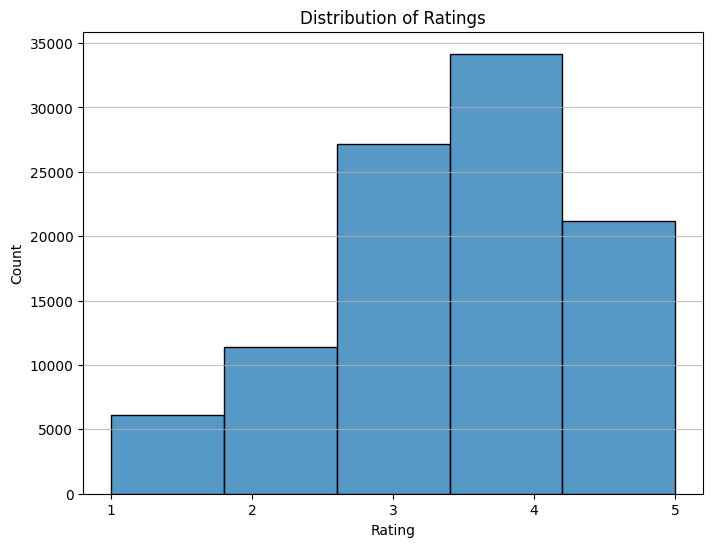

In [46]:
plt.figure(figsize=(8, 6))
sns.histplot(df['rating'], bins=5, kde=False)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(range(1, 6))
plt.grid(axis='y', alpha=0.75)
plt.show()

# Original

In [47]:
# Number of movies a user rated
user_rating_counts = df.groupby('user_id')['rating'].count()
print("Number of ratings per user calculated successfully.")
print(user_rating_counts.head())

# Number of users who rated the movie
item_rating_counts = df.groupby('item_id')['rating'].count()
print("Number of ratings per item calculated successfully.")
print(item_rating_counts.head())

print()

user_average_ratings = df.groupby('user_id')['rating'].mean()
print("Average ratings per user calculated successfully.")
item_average_ratings = df.groupby('item_id')['rating'].mean()
print("Average ratings per item calculated successfully.")

Number of ratings per user calculated successfully.
user_id
1    272
2     62
3     54
4     24
5    175
Name: rating, dtype: int64
Number of ratings per item calculated successfully.
item_id
1    452
2    131
3     90
4    209
5     86
Name: rating, dtype: int64

Average ratings per user calculated successfully.
Average ratings per item calculated successfully.


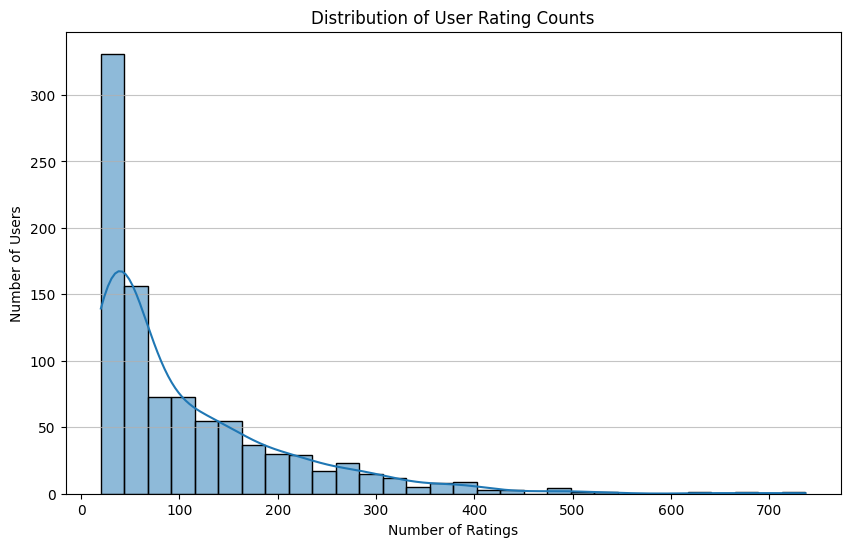

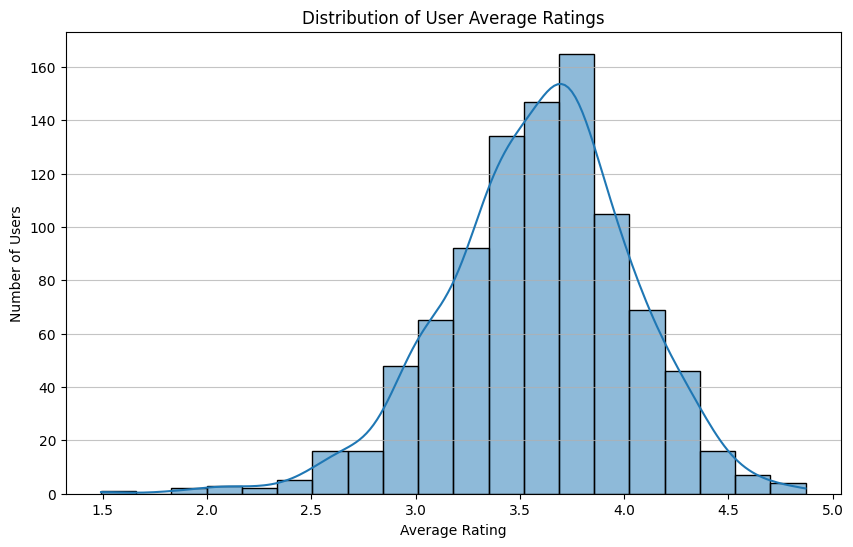

In [48]:
plt.figure(figsize=(10, 6))
sns.histplot(user_rating_counts, bins=30, kde=True)
plt.title('Distribution of User Rating Counts')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(user_average_ratings, bins=20, kde=True)
plt.title('Distribution of User Average Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Number of Users')
plt.grid(axis='y', alpha=0.75)
plt.show()


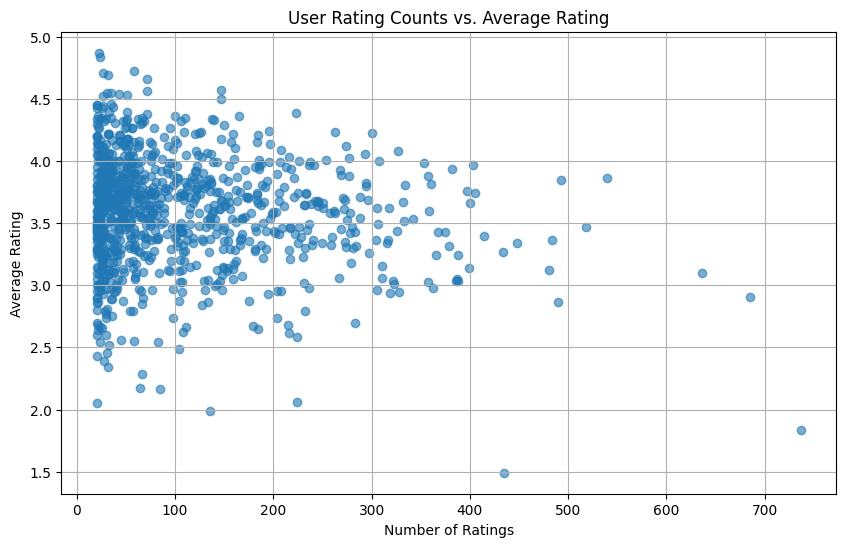

In [49]:
plt.figure(figsize=(10, 6))
plt.scatter(user_rating_counts, user_average_ratings, alpha=0.6)
plt.title('User Rating Counts vs. Average Rating')
plt.xlabel('Number of Ratings')
plt.ylabel('Average Rating')
plt.grid(True)
plt.show()

Merged DataFrame with user and item average ratings created successfully.


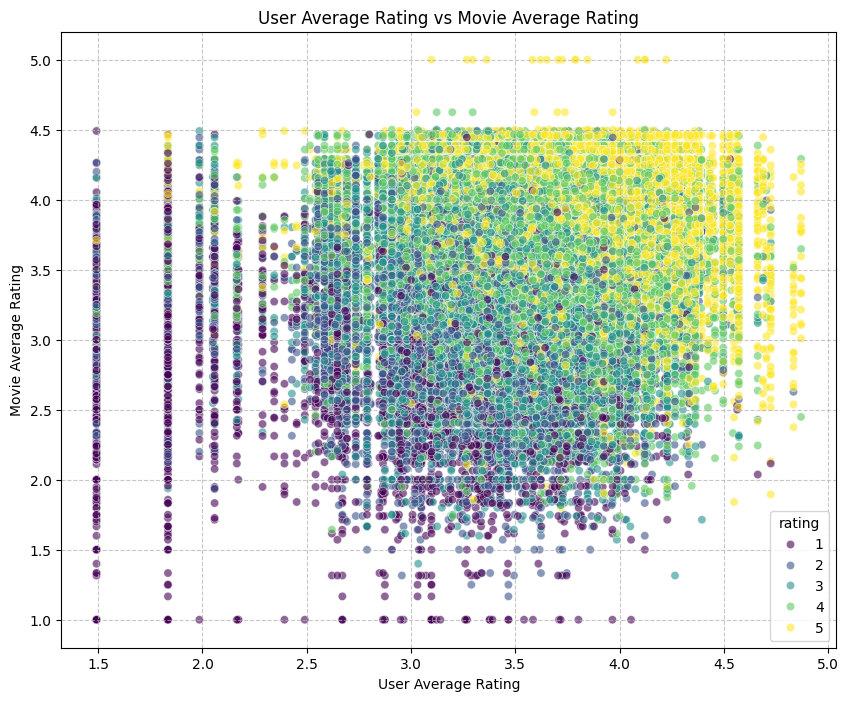

In [50]:
df_merged_averages = df.merge(user_average_ratings.rename('user_avg_rating'), on='user_id', how='left')
df_merged_averages = df_merged_averages.merge(item_average_ratings.rename('item_avg_rating'), on='item_id', how='left')
print("Merged DataFrame with user and item average ratings created successfully.")

plt.figure(figsize=(10, 8))
sns.scatterplot(x='user_avg_rating', y='item_avg_rating', hue='rating', data=df_merged_averages, alpha=0.6, palette='viridis', legend='full')
plt.title('User Average Rating vs Movie Average Rating')
plt.xlabel('User Average Rating')
plt.ylabel('Movie Average Rating')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [51]:
print("Original:")
print("Users:", df.user_id.nunique())
print("Movies:", df.item_id.nunique())
print("Mean:", df.rating.mean())
print("Median:", df.rating.median())
print("Standard Dev:", df.rating.std())

Original:
Users: 943
Movies: 1682
Mean: 3.52986
Median: 4.0
Standard Dev: 1.125673599144129


# FILTERING THE DATA

In [52]:
# Identify users with an average rating less than 2.3
user_less_than_2_3 = user_average_ratings[user_average_ratings < 2.3].index
user_more_than_4_6 = user_average_ratings[user_average_ratings > 4.6].index
print(f"Number of users to be removed: {len(user_less_than_2_3) + len(user_more_than_4_6)}")

df_filtered = df[~df['user_id'].isin(user_less_than_2_3)]
df_filtered = df_filtered[~df_filtered['user_id'].isin(user_more_than_4_6)]

# Identify movies with an average rating less than 1.5 and more than 4.5
movie_less_than_1_5 = item_average_ratings[item_average_ratings < 1.5].index
movie_more_than_4_5 = item_average_ratings[item_average_ratings > 4.5].index
print(f"Number of movies to be removed: {len(movie_less_than_1_5) + len(movie_more_than_4_5)}")

df_filtered = df_filtered[~df_filtered['item_id'].isin(movie_less_than_1_5)]
df_filtered = df_filtered[~df_filtered['item_id'].isin(movie_more_than_4_5)]

print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape: {df_filtered.shape}")

Number of users to be removed: 14
Number of movies to be removed: 89
Original DataFrame shape: (100000, 4)
Filtered DataFrame shape: (97898, 4)


Merged DataFrame with user and item average ratings created successfully.


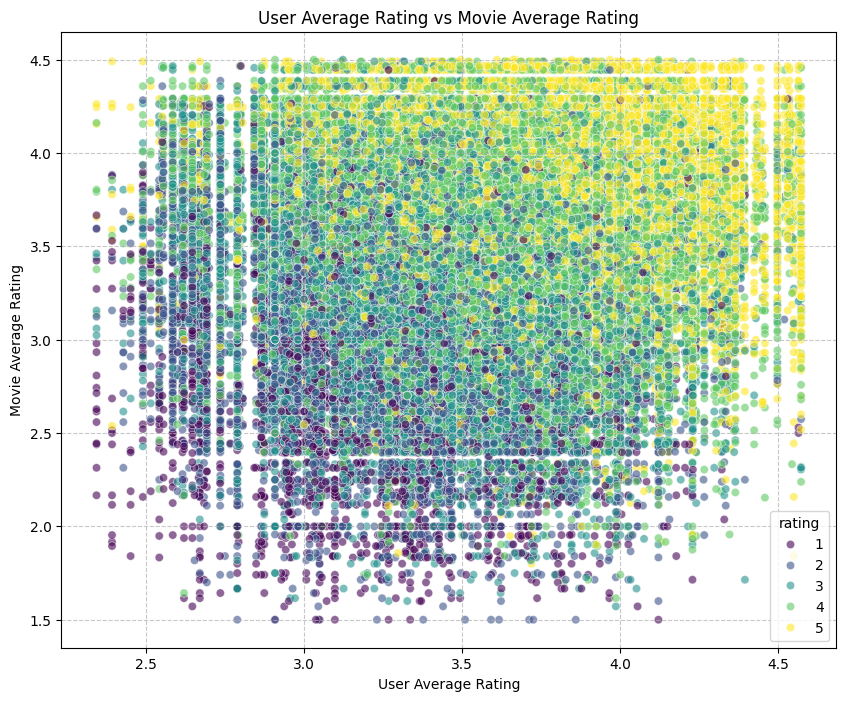

In [53]:
filtered_merged_averages = df_filtered.merge(user_average_ratings.rename('user_avg_rating'), on='user_id', how='left')
filtered_merged_averages = filtered_merged_averages.merge(item_average_ratings.rename('item_avg_rating'), on='item_id', how='left')
print("Merged DataFrame with user and item average ratings created successfully.")

plt.figure(figsize=(10, 8))
sns.scatterplot(x='user_avg_rating', y='item_avg_rating', hue='rating', data=filtered_merged_averages, alpha=0.6, palette='viridis', legend='full')
plt.title('User Average Rating vs Movie Average Rating')
plt.xlabel('User Average Rating')
plt.ylabel('Movie Average Rating')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Average ratings per user calculated successfully.
Number of ratings per user calculated successfully.
Average ratings per item calculated successfully.


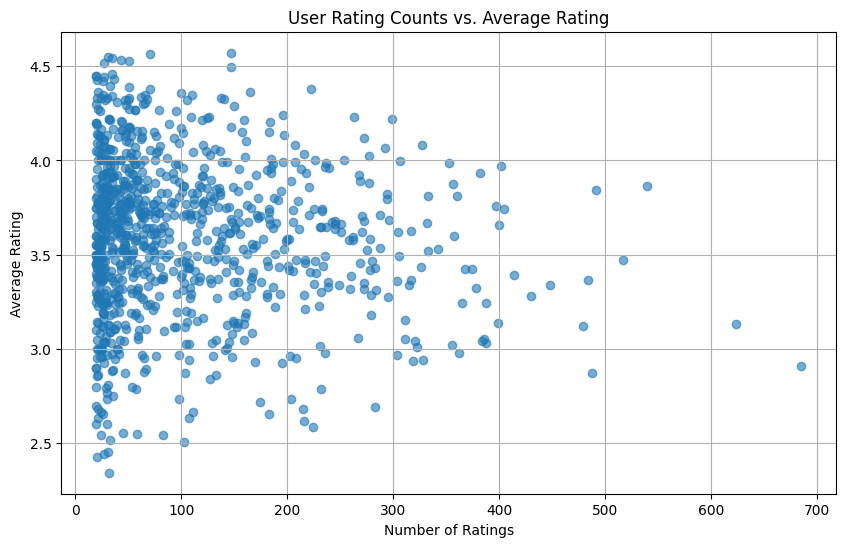

In [54]:
filtered_u_average_ratings = df_filtered.groupby('user_id')['rating'].mean()
print("Average ratings per user calculated successfully.")
filtered_u_rating_counts = df_filtered.groupby('user_id')['rating'].count()
print("Number of ratings per user calculated successfully.")

filtered_i_average_ratings = df_filtered.groupby('item_id')['rating'].mean()
print("Average ratings per item calculated successfully.")

plt.figure(figsize=(10, 6))
plt.scatter(filtered_u_rating_counts, filtered_u_average_ratings, alpha=0.6)
plt.title('User Rating Counts vs. Average Rating')
plt.xlabel('Number of Ratings')
plt.ylabel('Average Rating')
plt.grid(True)
plt.show()

In [55]:
print("Filtered:")
print("Users:", df_filtered.user_id.nunique())
print("Movies:", df_filtered.item_id.nunique())
print("Mean:", df_filtered.rating.mean())
print("Median:", df_filtered.rating.median())
print("Standard Dev:", df_filtered.rating.std())

Filtered:
Users: 929
Movies: 1593
Mean: 3.559030828004658
Median: 4.0
Standard Dev: 1.0978992708447837


# Verdict

## EDA Report

### Original Data:
  Original data is consistent with mean, median, and standard deviation scores of 3.52986, 4.0, 1.125673599144129 respectively.
  The data however, contained rogue user and movies average rating, which I treated as the outliers.
  Graphical presentations show the distributions and relationships.

### Filtered Data:
  Filtered data is a subset of the original one where the rogue/outliers were removed. Maybe will make more sense for the the algorithm.
  Mean, median, and standard deviations of the filtered data still give consisstent results with mean = 3.559030828004658, median = 4.0, and Standard deviation = 1.0978992708447837.


### Insights:
*   Users who generally give higher average ratings tend to rate items that also have higher average ratings.
*  A high individual rating is more likely to occur when both the user's average rating and the item's average rating are high.
*  Ratings cluster around the diagonal, suggesting that users tend to rate items consistently with their personal average rating and the item's general average rating.
* Data is skewed positively in both dataframes